In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/fraud-detection/fraudTest.csv
/kaggle/input/fraud-detection/fraudTrain.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
train_df = pd.read_csv('/kaggle/input/fraud-detection/fraudTrain.csv')


In [4]:
print(train_df.shape)
print(train_df.info())
train_df.describe()

(1296675, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


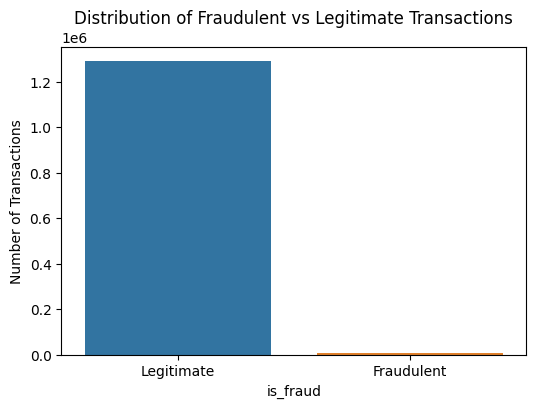

In [5]:
# 4. Target Variable Distribution
fraud_counts = train_df['is_fraud'].value_counts()
plt.figure(figsize=(6,4))
sns.barplot(x=fraud_counts.index, y=fraud_counts.values)
plt.title('Distribution of Fraudulent vs Legitimate Transactions')
plt.xticks([0, 1], ['Legitimate', 'Fraudulent'])
plt.ylabel('Number of Transactions')
plt.show()


In [6]:
print(f"Fraudulent transactions percentage: {round(fraud_counts[1]/sum(fraud_counts)*100, 2)}%")

Fraudulent transactions percentage: 0.58%


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


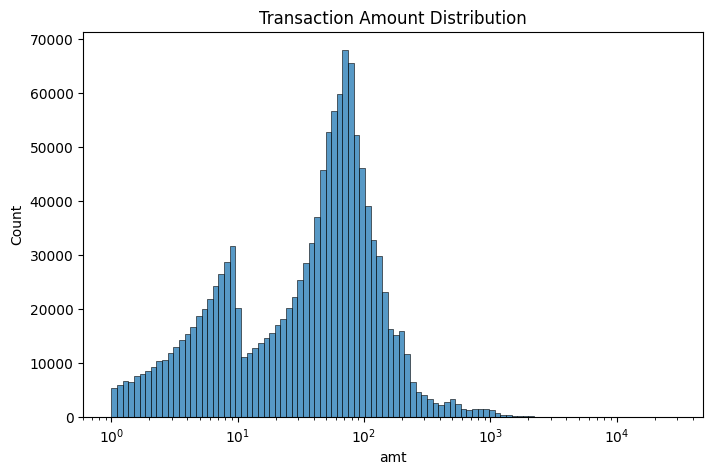

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(train_df['amt'], bins=100, log_scale=True)
plt.title('Transaction Amount Distribution')
plt.show()

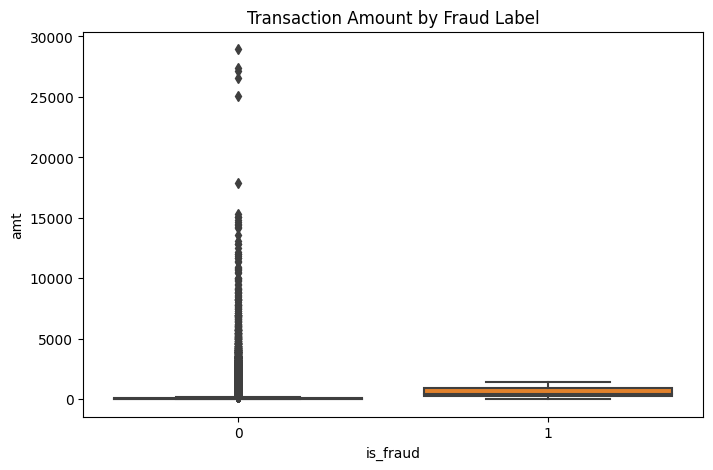

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(x='is_fraud', y='amt', data=train_df)
plt.title('Transaction Amount by Fraud Label')
plt.show()

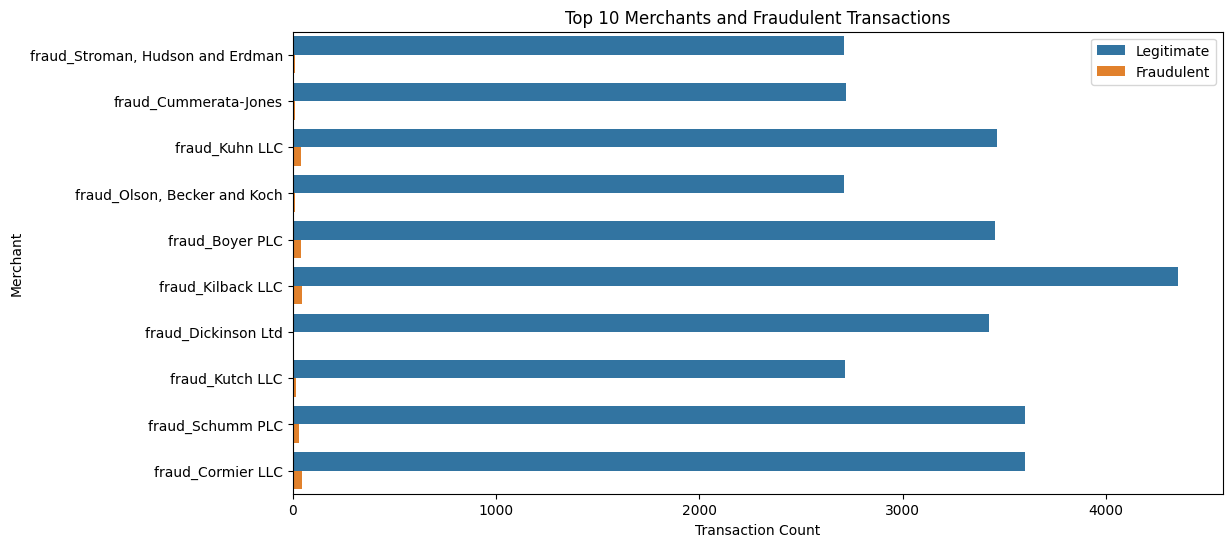

In [9]:
top_merchants = train_df['merchant'].value_counts().nlargest(10).index
merchant_df = train_df[train_df['merchant'].isin(top_merchants)]

plt.figure(figsize=(12,6))
sns.countplot(data=merchant_df, y='merchant', hue='is_fraud')
plt.title('Top 10 Merchants and Fraudulent Transactions')
plt.xlabel('Transaction Count')
plt.ylabel('Merchant')
plt.legend(['Legitimate', 'Fraudulent'])
plt.show()

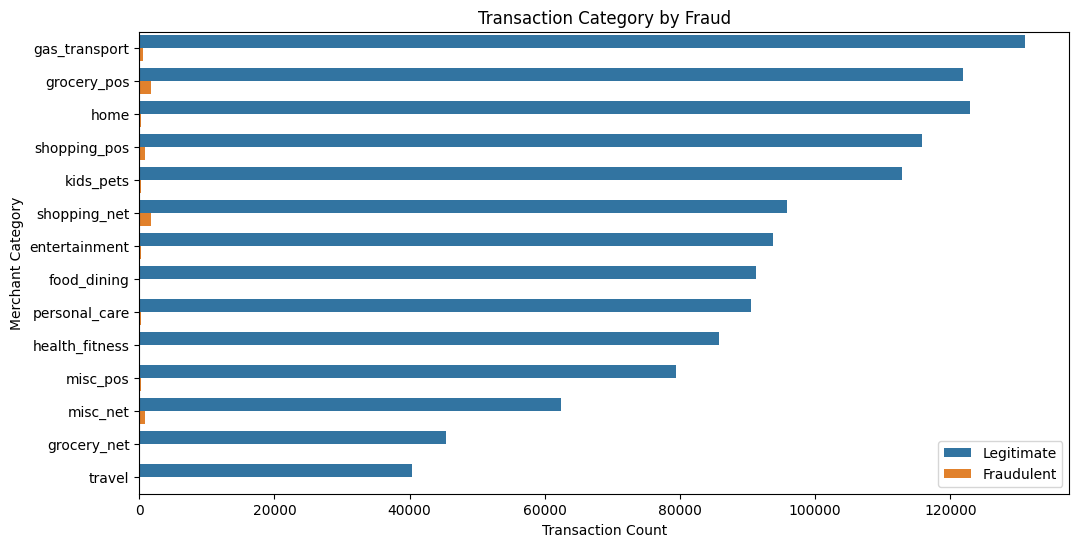

In [10]:
plt.figure(figsize=(12,6))
sns.countplot(data=train_df, y='category', order=train_df['category'].value_counts().index, hue='is_fraud')
plt.title('Transaction Category by Fraud')
plt.xlabel('Transaction Count')
plt.ylabel('Merchant Category')
plt.legend(['Legitimate', 'Fraudulent'])
plt.show()

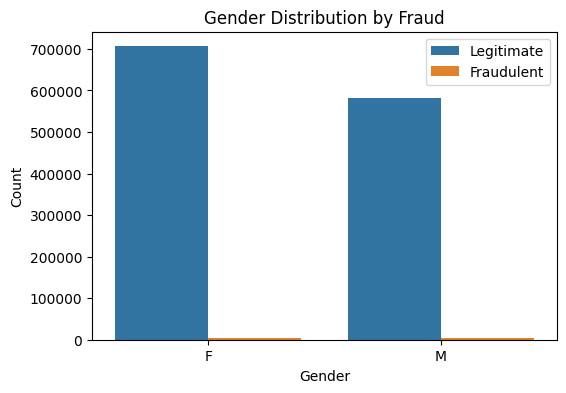

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(data=train_df, x='gender', hue='is_fraud')
plt.title('Gender Distribution by Fraud')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(['Legitimate', 'Fraudulent'])
plt.show()

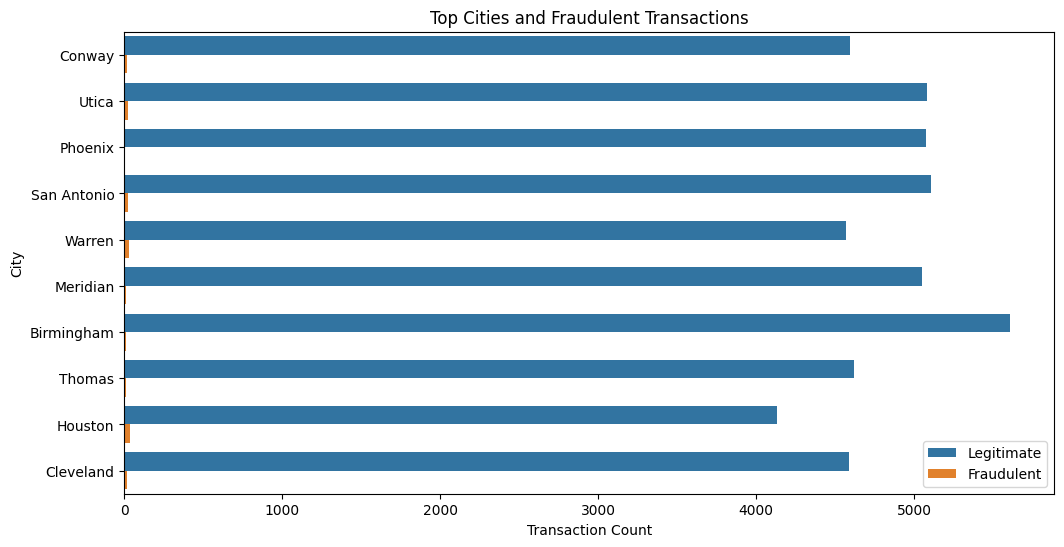

In [12]:
top_cities = train_df['city'].value_counts().nlargest(10).index
city_df = train_df[train_df['city'].isin(top_cities)]

plt.figure(figsize=(12,6))
sns.countplot(data=city_df, y='city', hue='is_fraud')
plt.title('Top Cities and Fraudulent Transactions')
plt.xlabel('Transaction Count')
plt.ylabel('City')
plt.legend(['Legitimate', 'Fraudulent'])
plt.show()

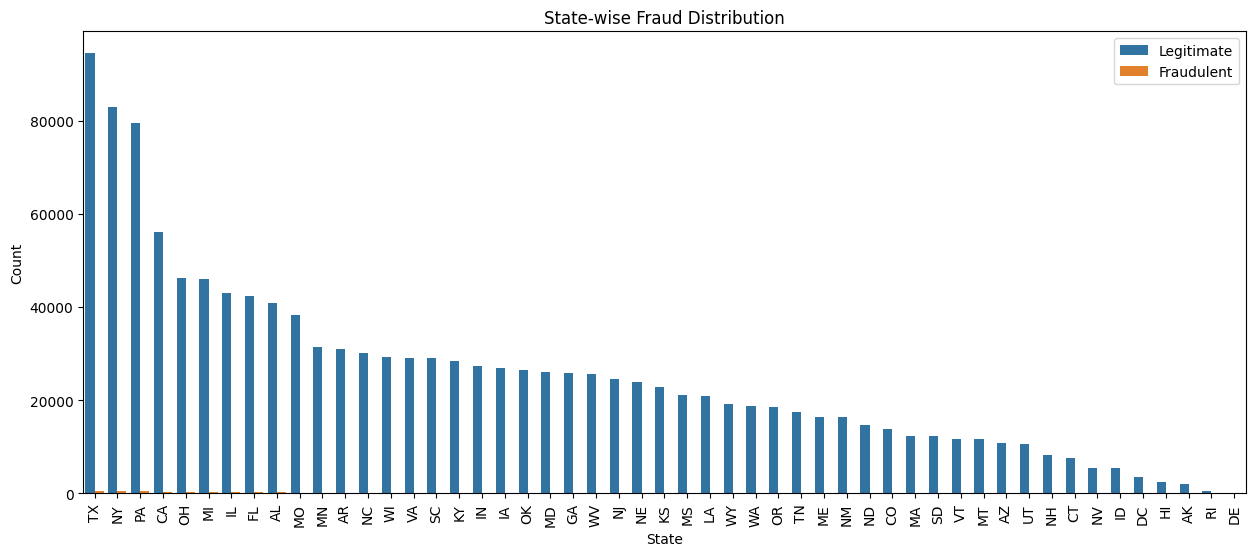

In [13]:
plt.figure(figsize=(15,6))
sns.countplot(data=train_df, x='state', order=train_df['state'].value_counts().index, hue='is_fraud')
plt.title('State-wise Fraud Distribution')
plt.xlabel('State')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.legend(['Legitimate', 'Fraudulent'])
plt.show()

In [14]:
train_df['trans_date_trans_time'] = pd.to_datetime(train_df['trans_date_trans_time'])
train_df['hour'] = train_df['trans_date_trans_time'].dt.hour
train_df['day'] = train_df['trans_date_trans_time'].dt.day
train_df['month'] = train_df['trans_date_trans_time'].dt.month

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

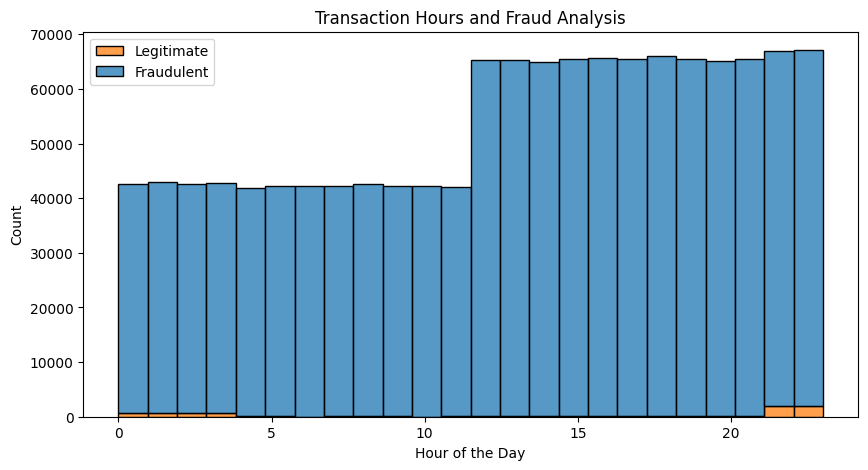

In [15]:
plt.figure(figsize=(10,5))
sns.histplot(data=train_df, x='hour', bins=24, hue='is_fraud', multiple='stack')
plt.title('Transaction Hours and Fraud Analysis')
plt.xlabel('Hour of the Day')
plt.ylabel('Count')
plt.legend(['Legitimate', 'Fraudulent'])
plt.show()